### Heart Failure Prediction Dataset

#### This dataset contains 11 features that can be used to predict possible heart disease.

#### I will implement Tree Ensemble models (Random Forest and XGBoost models) and evaluate them.

#### Complete workflow is done by myself.

In [ ]:
import pandas as pd
import numpy as np


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import os       

In [ ]:
file_path = str(r"c:\Users\Admin\ML-concepts\datasets\heart.csv")
df = pd.read_csv(file_path)

In [ ]:
df.head()

Attribute Information

    Age: age of the patient [years]
    Sex: sex of the patient [M: Male, F: Female]
    ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
    RestingBP: resting blood pressure [mm Hg]
    Cholesterol: serum cholesterol [mm/dl]
    FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
    RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
    MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
    ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
    Oldpeak: oldpeak = ST [Numeric value measured in depression]
    ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
    HeartDisease: output class [1: heart disease, 0: Normal]


### Target: HeartDisease -> Binary classification 

- 0 no disease

- 1 disease



### **EDA**

In [217]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
y.value_counts()

# balanced 

total = y.value_counts().sum()

df_y = pd.DataFrame(y.value_counts())
df_y['percentage'] = df_y['count'].apply(lambda row: row/total).round(2)
df_y # equal class

,count,percentage
HeartDisease,,
1,508,0.55
0,410,0.45


### Distribution of positive and negative class is fine, no need to stratify 

#### 1.1 Numerical features:

In [ ]:
df.select_dtypes(include='number')

### Scale of numerical feature is different, but since I will use Tree based models, there is no need to implement data scaling/normalization

### Numerical features descriptive statistics:

- 918 instances

In [ ]:
df.describe().round(2)

### 1.2 Categorical features

In [ ]:

categorical =  df.select_dtypes(exclude='number')
categorical

### Inspection of each category and it's value counts:

In [ ]:
for col in categorical.columns:
    print(categorical[col].value_counts())

1) Sex - binary

2) ChestPainType - Unordered categorical variable (nominal) - candidate for OneHotEncoder

3) RestingECG - Normal, LVH - Left Ventricular hyperthropy (worse patient health), ST - T inversion - Candidate for OrdinalEncoding of this feature (worsening of the patient health)

4) ExerciseAngina - Binary

5) ST_SLope - flat , up , down - cnadidate for ordinal encoder.

### 1.3 Correlation heatmap for numeric features /w Target feature (Normalized Variance [-1,1])

- Correlation is matrix of [ features x features ] that shows the interaction between each numeric feature

- Positive annotation -> increasing in one feature leads to increasing in another

- Negatve -> increasing in one leads to decreasing in another and vice versa

- If feature has negative correlation with a Target Feature, it does not mean that feature should be excluded. Correlation does not imply causality.

In [ ]:
numeric = df.select_dtypes(include='number')

sns.heatmap(numeric.corr().round(2),cmap='RdBu',annot=True)

### 1.4 EDA visualisation of the data ( Numerical features ):

1) **using correlation matrix to plot meaningful data correlation**


In [ ]:
corr_matrix = numeric.corr()
corr_matrix

In [ ]:
# FastingBS (numeric but not continous!)

numeric['FastingBS'].value_counts()

In [ ]:
abs(corr_matrix)>0.2

In [ ]:
# Cholesterol - FastingBS & MaxHR
# FastingBS - MaxHR
# MaxHR - Age

features = ['Cholesterol','MaxHR']

# Check missing values 

numeric['Cholesterol'].value_counts()
# 172 missing values!
numeric['MaxHR'].value_counts()

In [ ]:
clean_df_plot = numeric[numeric['Cholesterol']>0]
plt.scatter(clean_df_plot['Cholesterol'],clean_df_plot['MaxHR'],alpha=0.5)
plt.xlabel("Cholesterol")
plt.ylabel("Max HeartRate")
plt.title('Cholesterol VS MaxHR')
plt.show()

#### Plot implies that there is no evident relationship between increase in Cholesterol nad Maximum Heart Rate in the patient data

In [ ]:
sns.boxplot(data=numeric,x='FastingBS',y='MaxHR')

### Helper function to visualize boxplot of Target/Feature and it's distribution and how it affecets the patient state:

In [ ]:
# x axis will be HeartDisease -> target var
# y axis will be other features 
# boxplot 

def plot_boxplot(X):

    x1 = 'HeartDisease'
    features = X.columns[:-1] # exclude target
    n = len(features)
    print(features)
    fig,ax = plt.subplots(1,n,figsize=(10,6))

    for ax,feature in zip(ax.flatten(),features):
        sns.boxplot(data=X,x=x1,y=feature,ax=ax)
        plt.tight_layout()


In [ ]:
plot_boxplot(numeric)

### Summary of boxplot:

1) Age -> expected behaviour, showing that patients that are older have higher disease incidence, while having some outliers in the lower bound for positive class. From this data and dataset, we do not know anything about history of the patients, their lifestyle and maybe some co-morbidities present.

2) RestingBP -> Median for both classes is similar, while positive class has slighlty higher distribution spread, towrads the higher values of BP. We can not conclude that RestingBP affect the Heart Disease.

3) Cholesterol -> From the boxplot, we may conclude that Cholesterol is not such a good variable for discriminating between postiive and negative class. We need to take into consideration that Cholesterol variable has 170+ missing values, and like this, it's not informative.

4) Fasting Blood Sugar(BS) -> Almost completely evident, that patients with a disease have positive fasting blood glucose higher than 120mg/dl. These patients are considered prediabetic and diabetic. This can also indicate that patients may have additional metabolic diseases and should be taken into consideration

5) Max Heart Rate -> We see that patients with no disease have higher maximum heart rate, which could be explained by the heart capacity to sustain exercise.  Lower max heart rate , and evidently lower mean value, indicate that this variable is informative in prediction task 

6) Oldpeak (Degree of ST segment depression measured on ECG during a **stress test** compared to a baseline at rest) 

- During an exercise, heart works harder to pump blood. If patient has some arterial plaque or calcification, they cannot supply enoguh bloodflow

- This shortage causes downward shift (depression) in the ECG ST segment

- downward shift >= 1.5-2 is implying significant indicator of coronar artery disease. 

In [ ]:
#resting bp , max hr and cholesterol

clean = numeric[(numeric['Cholesterol']>0) & (numeric['Cholesterol']!=np.nan)]

sns.scatterplot(data=clean,x='MaxHR',y='RestingBP',hue='Oldpeak')

### Cholesterol - has missing values. -> Candidate for imputation in the preprocessing

I need to implment correction for these variables

In [ ]:
# Cholesterol
# in the original dataset:

df['Cholesterol'] = df['Cholesterol'].replace(0,np.nan)
df['Cholesterol'].isna().sum() # 172 sum values


### **1.4 EDA visualisation of the data ( Categorical features )**

In [ ]:
# categorical features from dataset

categorical = df.select_dtypes(exclude='number')
categorical

In [ ]:
categorical.groupby("RestingECG")['Sex'].describe()

In [ ]:
categorical.groupby('ExerciseAngina')['RestingECG'].describe()

In [ ]:
categorical

### **Preprocessing**

- Train/Test split

- Column Transformer + Pipe

- Missing values imputation

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(f'X_Train :{X_train.size}')
print(f"X_test:{X_test.size}")


In [ ]:
chol = df['Cholesterol'].isna()==True
chol.sum()
z = chol.sum()/len(df)
z # 18% of feature has missing values

df['Cholesterol'].describe()
# mean imputation would be suitable

In [ ]:
df.isna().sum()

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

In [ ]:
for col in categorical.columns:
    print(col,categorical[col].unique())

**ST_SLOPE** -> Ordinal categories, have rank from mild to worse condition up -> flat -> down

In [ ]:
slope_size = categorical['ST_Slope'].unique()
slope_size

In [ ]:
preprocessing = ColumnTransformer(transformers=[
    ('imputer',SimpleImputer(strategy='mean'),['Cholesterol']),
    ('labelEncoder',OrdinalEncoder(),['Sex','ExerciseAngina']),
    ('OrdinalEncoder',OrdinalEncoder(categories=[slope_size]),['ST_Slope']),
    ('Ohe',OneHotEncoder(),['ChestPainType','RestingECG','ExerciseAngina'])],
    remainder='passthrough')

## Preprocessing test on SingleTree

In [ ]:
mini_pipe = make_pipeline(
    preprocessing,
    DecisionTreeClassifier()
)

mini_pipe.fit(X_train,y_train)

In [ ]:
from sklearn.metrics import precision_score,recall_score,classification_report
y_pred = mini_pipe.predict(X_test)
report = classification_report(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
print(precision)
print(recall)
print(report)

## **Modeling** - Baseline with crossvalidation (k=5)

### Models: 

- Single Classification Tree (baseline)

- RandomForest

- XGCBoost

### Scores:

- f1

- precision

- accuracy

- roc_auc

- precision_recall

In [ ]:
from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.metrics import accuracy_score,precision_recall_curve,roc_auc_score,roc_curve,f1_score



In [ ]:
models = {
    'Tree':DecisionTreeClassifier(random_state=42),
    'Forest':RandomForestClassifier(random_state=42),
    'Xboost':XGBClassifier(random_state=42)
}

In [ ]:
# pipeline (preprocessing + model) 

complete_pipeline = {}

for name,model in models.items():
    make_pipe = make_pipeline(
        preprocessing,
        model
    )
    complete_pipeline[name] = make_pipe

In [ ]:
score_list = ['f1','accuracy','precision','recall','roc_auc']

def get_scores(X,y,pipe,scores,grid=False):
    score_storage = {}


    for name,estimator in pipe.items():
        score_storage[name] = {}

        for score in scores:
            result = cross_val_score(estimator,X,y,scoring=score,cv=5)
            score_storage[name][score] = result.mean().round(2)
    return score_storage


In [ ]:
score_storage_baseline = get_scores(X_train,y_train,complete_pipeline,score_list)

In [ ]:
pd_scores_baseline = pd.DataFrame(score_storage_baseline)
pd_scores_baseline.T.sort_values(by='f1',ascending=False)

In [317]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

y_preds = {}
y_probas = {}

for name,model in complete_pipeline.items():
    y_hat = cross_val_predict(model,X_train,y_train,cv=5,method='predict')
    y_preds[name]= y_hat
    probas = cross_val_predict(model,X_train,y_train,cv=5,method='predict_proba')[:,1]
    y_probas[name] = probas

In [ ]:
collect = {}
for name,preds in y_preds.items():
    cm = confusion_matrix(y_train,preds,labels=[0,1])
    tn,fp,fn,tp = cm.ravel()
    collect[name] = tn,fp,fn,tp
    z = ConfusionMatrixDisplay(cm,display_labels=['No Disease','Disease'])
    z.plot()
    z.ax_.set_title(f'{name}-model')
print(collect)

In [222]:
df_y['count'].loc[1] 

np.int64(508)

In [ ]:
values_df = pd.DataFrame(collect)

In [ ]:
values_df.rename(mapper={0:'tn',1:'fp',2:'fn',3:'tp'},inplace=True)

In [ ]:
values_df.T.sort_values(by='tp',ascending=False)

### RandomForest baseline model shows highest number of **True Positives**/**False Negatives**

- In this data science problem, it is important to have least false negative and a lot of true positives 

- we want to capture all positive samples and eliminate most of false negatives. We dont want to say to a patient that he is not sick , and he is actually sick (Type 2 eror)

In [ ]:
values_df

In [ ]:

pd_scores_baseline

In [ ]:
print(np.linspace(0,1,100))

In [205]:
precision

0.8736842105263158

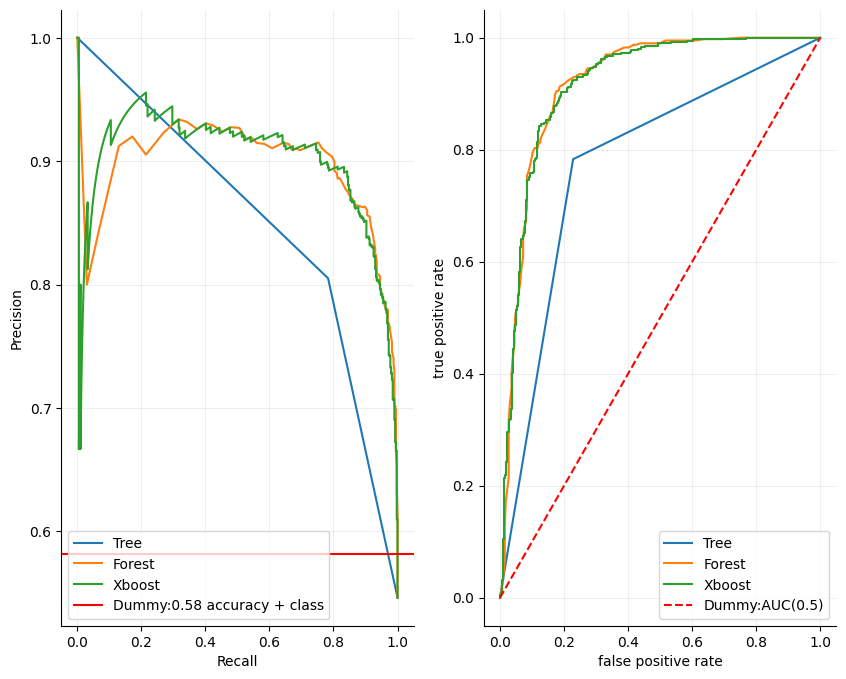

In [318]:
# ROC auc and PR curve
def plot_curves(complete_pipe,y,y_proba):

    storage = {}
    positive_class = sum(y_test==1)/len(y_test)

    fig,ax = plt.subplots(1,2,figsize=(10,8))
    for name,model in complete_pipe.items():
        storage[name] = {}
        precision,recall,threshold_pr = precision_recall_curve(y,y_proba[name])
        fpr,tpr,threshold_roc = roc_curve(y,y_proba[name])
        storage[name]['pr'] = precision
        storage[name]['rec'] = recall
        storage[name]['fpr'] = fpr
        storage[name]['tpr'] = tpr
    
    for i,(name,model) in enumerate(complete_pipe.items()):
        ax[0].plot(storage[name]['rec'],storage[name]['pr'],label=f"{name}")
        ax[1].plot(storage[name]['fpr'],storage[name]['tpr'],label=f"{name}")
    
    # Dummy classifier
    ax[0].axhline(positive_class,linestyle='-',color='red',label='Dummy:0.58 accuracy + class')
    ax[1].plot([0,1],[0,1],color='red',linestyle='--',label='Dummy:AUC(0.5)')
    
    ax[0].set_xlabel('Recall')
    ax[0].set_ylabel('Precision')
    ax[1].set_xlabel("false positive rate")
    ax[1].set_ylabel("true positive rate")
    for i in range(len(ax)):
        ax[i].grid(alpha=0.2)
        ax[i].legend()
        ax[i].spines[['top','right']].set_visible(False)

z = plot_curves(complete_pipeline,y_train,y_probas)

### Precision Recall curve:

- Trade off between precision and recall. At highest values of precision, recall value is low. At low values of recal , precision suddenly drops and then stabilizes at high value. We aim to find a dot that points at highest value of recall with the possible highest value of precision. Since my goal is to detect most True Classes and less False negatives

### ROC curve:

It shows how well model can distinguish between positive and negative class. Red line represets the DummyClassifier which represents random class assign.


### We may see from the graph that RandomForest keeps highest precision for the highest values of recall

### Hyperparameters:

DT Hyperparameters are external configuration settings used to control the structure, growth, and complexity of a decision tree model. 

Because unconstrained decision trees naturally grow until they completely memorize the training data, tuning these settings is the primary defense 

against __overfitting__.



In [280]:
parameters = {
    'Tree':{'decisiontreeclassifier__max_depth':[1,2,3,4,6,8,16],'decisiontreeclassifier__min_samples_split':[2,4,8,16,32,64,128]},
    'Forest':{'randomforestclassifier__n_estimators':[10,50,100,500],'randomforestclassifier__min_samples_split':[2,4,8,16,32,64,128],'randomforestclassifier__max_depth':[2, 4, 8, 16]},
    'Xboost':{'xgbclassifier__n_estimators':[500],'xgbclassifier__learning_rate':[0.05,0.1,0.2,0.4],'xgbclassifier__verbosity':[1],'xgbclassifier__subsample':[0.8,1]}
            
}

#### All 3 models defined in the upper cell are tree based, thus they can use initial column_transformer ( same transformations are applied to same columns)

- preprocessing

In [ ]:
preprocessing

## GridSearchCV

- Class used for exhaustive search for parameters predefined 

- GridSearchCV try all possible combination of parameters:

example: 

max_depth: [2,4,7]
min_samples_leaf: [2,4,8]

**9 times the model is fit**

**While this can be computationally expensive, it's the best method to obtain best parameters in small-medium param. grid size.**

### Alternative: RandomizedSearchCV -> Picks random parameters to train the model **best used for small grids and fast execution**
---
**GridSearchCV**

- estimator

- param_grid: list or list of dicts with parameters 

- scoring

- n_jobs: -1 all cores utilization

- refit: **default: True** -> refits the estimator with best found parameters on the whole dataset

- cv: CV splitting strategy, specify k (number of folds used for test , k - 1 for training)

In [377]:
def grid_search(X,y,pipe,params,cv):

    grid_output = {}

    for name,model in pipe.items():
        grid_output[name] = {}
        estimator = model
        pars = params[name]
        g = GridSearchCV(estimator,pars,cv=cv,verbose=1,n_jobs=-1,scoring='f1',refit=True)
        g.fit(X,y)
        grid_output[name]['best_model'] = g.best_estimator_
        grid_output[name]['best_scores'] =g.best_score_
        grid_output[name]['cv_results'] = g.cv_results_
        grid_output[name]['best_params'] = g.best_params_
    return grid_output

tuning_output = grid_search(X_train,y_train,complete_pipeline,parameters,5)
print(z)

Fitting 5 folds for each of 49 candidates, totalling 245 fits
Fitting 5 folds for each of 112 candidates, totalling 560 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
None


In [ ]:
best_models = {}
for name,values in tuning_output.items():
    print(values)
    best_models[name] = values['best_model']

{'best_model': Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer', SimpleImputer(),
                                                  ['Cholesterol']),
                                                 ('labelEncoder',
                                                  OrdinalEncoder(),
                                                  ['Sex', 'ExerciseAngina']),
                                                 ('OrdinalEncoder',
                                                  OrdinalEncoder(categories=[array(['Up', 'Flat', 'Down'], dtype=object)]),
                                                  ['ST_Slope']),
                                                 ('Ohe', OneHotEncoder(),
                                                  ['ChestPainType',
                                                   'RestingECG',
                                                   'ExerciseAngin

In [319]:
collect_df_optimized = {}
probas_2 = {}
for name,model in best_models.items():
    collect_df_optimized[name] = {}
    probas_2[name] = {}
    y_preds = cross_val_predict(model,X_train,y_train,cv=5,method='predict')
    y_probas = cross_val_predict(model,X_train,y_train,cv=5,method='predict_proba')[:,1]
    probas_2[name] = y_probas
    for score in score_list:
        scores = cross_val_score(model,X_train,y_train,cv=5,scoring=score)
        collect_df_optimized[name][score] = scores.mean()

    

In [320]:
collect_df_optimized = pd.DataFrame(collect_df_optimized)

In [321]:
collect_df_optimized.sort_values(by='f1',ascending=False,axis=1)


,Forest,Xboost,Tree
f1,0.890701,0.861838,0.850025
accuracy,0.877374,0.847386,0.829671
precision,0.870259,0.857401,0.821123
recall,0.912747,0.867932,0.882809
roc_auc,0.921272,0.916101,0.867852


### PR and ROC curve with optimized hyperparameters:

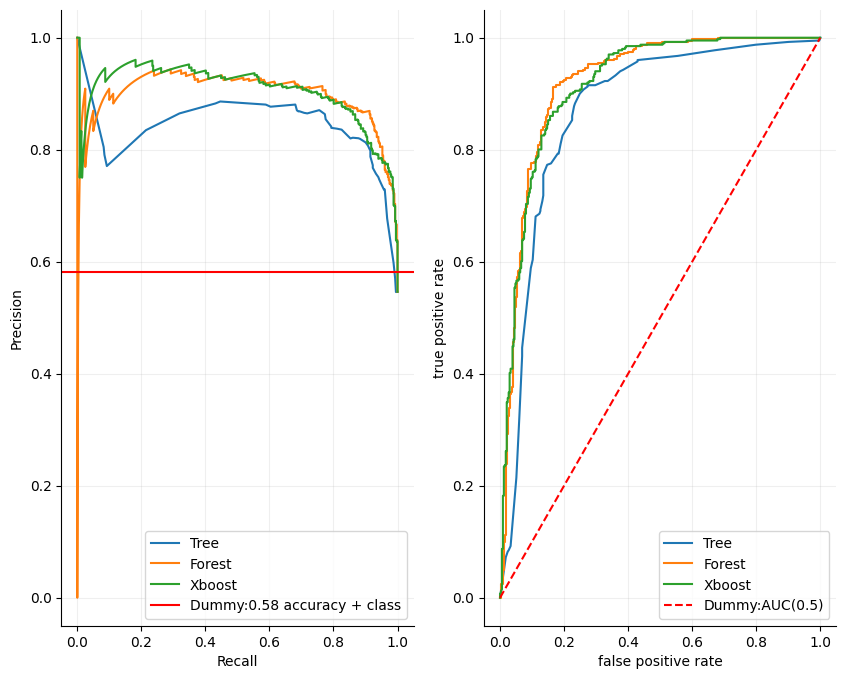

In [322]:
p = plot_curves(best_models,y_train,probas_2)

In [331]:
collect_df_optimized.sort_values(by='f1', ascending=False,axis=1).round(2)

,Forest,Xboost,Tree
f1,0.89,0.86,0.85
accuracy,0.88,0.85,0.83
precision,0.87,0.86,0.82
recall,0.91,0.87,0.88
roc_auc,0.92,0.92,0.87


In [330]:
pd_scores_baseline.sort_values(by='f1',ascending=False,axis=1)

,Forest,Xboost,Tree
f1,0.88,0.87,0.79
accuracy,0.87,0.86,0.78
precision,0.86,0.86,0.81
recall,0.90,0.89,0.78
roc_auc,0.92,0.92,0.78


In [334]:
data_difference = pd_scores_baseline.compare(collect_df_optimized)

In [350]:
data_difference.rename(mapper={'self':'baseline','other':'tuned_parameters'},axis=1,inplace=True)

In [351]:
data_difference

Tree                    Forest                    Xboost  \
          baseline tuned_parameters baseline tuned_parameters baseline   
f1            0.79         0.850025     0.88         0.890701     0.87   
accuracy      0.78         0.829671     0.87         0.877374     0.86   
precision     0.81         0.821123     0.86         0.870259     0.86   
recall        0.78         0.882809     0.90         0.912747     0.89   
roc_auc       0.78         0.867852     0.92         0.921272     0.92   

                            
          tuned_parameters  
f1                0.861838  
accuracy          0.847386  
precision         0.857401  
recall            0.867932  
roc_auc           0.916101

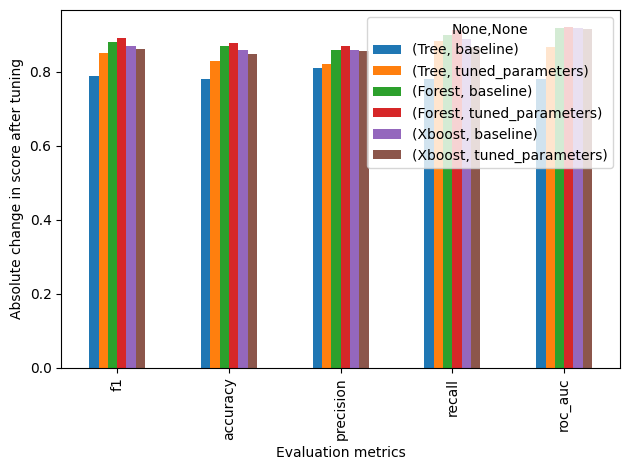

In [361]:
data_difference.plot(kind='bar')
plt.xlabel('Evaluation metrics')
plt.ylabel('Absolute change in score after tuning')
plt.tight_layout()


In [363]:
best_models.values()

dict_values([Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer', SimpleImputer(),
                                                  ['Cholesterol']),
                                                 ('labelEncoder',
                                                  OrdinalEncoder(),
                                                  ['Sex', 'ExerciseAngina']),
                                                 ('OrdinalEncoder',
                                                  OrdinalEncoder(categories=[array(['Up', 'Flat', 'Down'], dtype=object)]),
                                                  ['ST_Slope']),
                                                 ('Ohe', OneHotEncoder(),
                                                  ['ChestPainType',
                                                   'RestingECG',
                                                   'ExerciseAngina'

In [400]:
tuning_output['Tree'].keys()

dict_keys(['best_model', 'best_scores', 'cv_results', 'best_params'])

### Score on validation fold on X_train set:

- scoring metric has been set to f1

- ['mean_test_score'] gives score on validation fold during CV.

In [408]:
tuning_output['Forest']['cv_results'].keys() # scoring parameter is set to 'f1' 
#tuning_output['Forest']['cv_results']['std_test_score'].mean()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_randomforestclassifier__max_depth', 'param_randomforestclassifier__min_samples_split', 'param_randomforestclassifier__n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

Dakle ono sto je bitno jeste da prikupim ceo output iz grid_output-a u recnik. 

Svaki model mora da ima best_estimator_, best_scores_, best_params_ i cv_results_

1) __best_estimator___ predstavlja model sa najboljom kombinacijom parametara -> daje najveci mean_test_score koji je odredjen metrikom u Gridu **scoring=f1**

2) __best_scores___ predstavlja najbolji mean cross-validovani skroz dobijen iz validation-folda tokom treniranja-> ovo je mean tih skorova iz svakog fold-a

3) __best_params___ predstavlja najbolje parametre koji imaju najveci mean test skor dobijen cross validacijom na validacionim foldovima

4) __cv_results___ dict sa svim metrikama

In [419]:
# Select FOREST

cv_df = pd.DataFrame(tuning_output['Forest']['cv_results'])
print(cv_df.columns)
cv_df[['mean_test_score','std_test_score','rank_test_score','params']].sort_values(by='mean_test_score',ascending=False)

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_randomforestclassifier__max_depth',
       'param_randomforestclassifier__min_samples_split',
       'param_randomforestclassifier__n_estimators', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='object')


,mean_test_score,std_test_score,rank_test_score,params
61,0.890701,0.014274,1,"{'randomforestclassifier__max_depth': 8, 'rand..."
87,0.884436,0.019631,2,"{'randomforestclassifier__max_depth': 16, 'ran..."
91,0.883532,0.016579,3,"{'randomforestclassifier__max_depth': 16, 'ran..."
90,0.882999,0.021177,4,"{'randomforestclassifier__max_depth': 16, 'ran..."
66,0.882697,0.027946,5,"{'randomforestclassifier__max_depth': 8, 'rand..."
...,...,...,...,...
16,0.846730,0.020942,106,"{'randomforestclassifier__max_depth': 2, 'rand..."
4,0.846730,0.020942,106,"{'randomforestclassifier__max_depth': 2, 'rand..."
0,0.846730,0.020942,106,"{'randomforestclassifier__max_depth': 2, 'rand..."
8,0.846730,0.020942,106,"{'randomforestclassifier__max_depth': 2, 'rand..."


In [433]:
cv_df.loc[cv_df['rank_test_score']==1,['mean_test_score','std_test_score','rank_test_score','params']]

,mean_test_score,std_test_score,rank_test_score,params
61,0.890701,0.014274,1,"{'randomforestclassifier__max_depth': 8, 'rand..."


In [522]:
# mean_test_score visok
# std nizak
# best 1% - highest mean test score

best_mean_score = cv_df['mean_test_score'].max()
best_mean_score
candidate = cv_df.loc[cv_df['mean_test_score']>=best_mean_score-0.01,['mean_test_score','std_test_score','rank_test_score','params']].sort_values(by='std_test_score',ascending=True)
candidate

,mean_test_score,std_test_score,rank_test_score,params
61,0.890701,0.014274,1,"{'randomforestclassifier__max_depth': 8, 'rand..."
91,0.883532,0.016579,3,"{'randomforestclassifier__max_depth': 16, 'ran..."
67,0.881677,0.017076,7,"{'randomforestclassifier__max_depth': 8, 'rand..."
63,0.882235,0.018108,6,"{'randomforestclassifier__max_depth': 8, 'rand..."
59,0.880861,0.019041,11,"{'randomforestclassifier__max_depth': 8, 'rand..."
87,0.884436,0.019631,2,"{'randomforestclassifier__max_depth': 16, 'ran..."
62,0.881157,0.020036,8,"{'randomforestclassifier__max_depth': 8, 'rand..."
93,0.881057,0.020045,9,"{'randomforestclassifier__max_depth': 16, 'ran..."
90,0.882999,0.021177,4,"{'randomforestclassifier__max_depth': 16, 'ran..."
97,0.880960,0.024913,10,"{'randomforestclassifier__max_depth': 16, 'ran..."


### mean_test_score -> sum of 'f1' score on validation fold in CrossValidation 

### std_test_score -> how each fold score vary. 

## **rank_test_score** -> most stable model **rank_test_score** = 1

Nakon Grid Search analize ne gledam samo najbolji mean_test_score koji predstavlja avg. f1 skora po validation foldovima CrossValidacije, vec gledam i varijaciju izmedju foldova. Manja varijacija izmedju test foldova predstavlja stabilniji model. U ovom slucaju, model sa kombinacijom parametara koja pripada rank_test_score = 1 predstavlja ujedno i najveci mean_test_score ali i najmanji std_test_score i biram ove parametre.

### Jednostavnom proverom parametara best_estimator_ iz Grid-a, vidimo da su hiperparametri bas ti koje smo i ovde izabrali rucno

In [533]:
best_models['Forest'].get_params

<bound method Pipeline.get_params of Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer', SimpleImputer(),
                                                  ['Cholesterol']),
                                                 ('labelEncoder',
                                                  OrdinalEncoder(),
                                                  ['Sex', 'ExerciseAngina']),
                                                 ('OrdinalEncoder',
                                                  OrdinalEncoder(categories=[array(['Up', 'Flat', 'Down'], dtype=object)]),
                                                  ['ST_Slope']),
                                                 ('Ohe', OneHotEncoder(),
                                                  ['ChestPainType',
                                                   'RestingECG',
                                           

In [534]:
selected_params_final = candidate.loc[candidate['rank_test_score']==1,'params']

In [586]:
selected_param_final_list = selected_params_final.to_list()[0]
selected_param_final_list

{'randomforestclassifier__max_depth': 8,
 'randomforestclassifier__min_samples_split': 4,
 'randomforestclassifier__n_estimators': 50}

In [587]:
prefix = 'randomforestclassifier__'
new_clean = {}

for name,value in selected_param_final_list.items():
    if name.startswith(prefix):
        new_clean[name[len(prefix):]] = value



In [588]:
new_clean

{'max_depth': 8, 'min_samples_split': 4, 'n_estimators': 50}

In [590]:
RF_final = RandomForestClassifier(**new_clean,random_state=42)
RF_final

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t